# Game Data Processing Pipeline

Validates and consolidates participant CSV files from `game_data/` into parquet files.
Supports incremental batch processing — already-processed participants are skipped.

**Expected data per participant:**
- `final_choice/final_choice_<pid>.csv` — 1 row, the selected round
- `pc_data/round_N_<pid>_pc.csv` — 5 files (N=1–5), each **60 rows** (5 gens × 2 vases × 6 PCs)
- `xy_data/round_N_<pid>_xy.csv` — 5 files, variable rows (250 xy points × 2 vases × 5 gens)
- `user_metadata/participant_<pid>_<sid>.csv` — 1 row

**Output parquet files** (in `processed/`):
- `pc_data.parquet`, `xy_data.parquet`, `metadata.parquet`, `final_choice.parquet`, `validation_log.parquet`

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, field
from typing import Optional
import re
import warnings

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Data subdirectories (final_choice/, pc_data/, xy_data/, user_metadata/)
# sit alongside the notebook — there is no game_data/ parent folder.
DATA_DIR   = Path("/Users/joshmt/vase.evolution@gmail.com - Google Drive/My Drive/PerfectVaseApp")
OUTPUT_DIR = Path("processed")
OUTPUT_DIR.mkdir(exist_ok=True)

EXPECTED_ROUNDS = 5
EXPECTED_GENS   = 5
EXPECTED_VASES  = 2
EXPECTED_PCS    = 6                                                    # PC1–PC6
EXPECTED_XY_POINTS = 250                                               # num_vase_points
EXPECTED_PC_ROWS_PER_ROUND = EXPECTED_GENS * EXPECTED_VASES * EXPECTED_PCS  # 60

# Max parallel workers for file I/O
MAX_WORKERS = 8

# Sanity-check that the expected subdirectories are reachable
for _sub in ("final_choice", "pc_data", "xy_data", "user_metadata"):
    assert (DATA_DIR / _sub).is_dir(), f"Directory not found: {(DATA_DIR / _sub).resolve()}"

print(f"DATA_DIR  : {DATA_DIR.resolve()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()}")
print(f"final_choice files found: {len(list((DATA_DIR / 'final_choice').glob('final_choice_*.csv')))}")

DATA_DIR  : /Users/joshmt/Library/CloudStorage/GoogleDrive-vase.evolution@gmail.com/My Drive/PerfectVaseApp
OUTPUT_DIR: /Users/joshmt/theperfectpot_analysis/file_processing/processed
final_choice files found: 2750


In [3]:
# ── Expected columns per data type ──

PC_REQUIRED_COLS = [
    "generation_key", "vase", "pc_name", "pc_value",
    "is_selected_vase", "is_parent_vase",
    "selection_elapsed_time_s", "decision_time_ms",
    "adjusted_selection_elapsed_time_s", "adjusted_decision_time_ms",
    "rt_onset_correction_ms",
    "rt_calibration_status", "rt_calibration_median_ms", "rt_calibration_trials_n",
    "participant_id", "session_id", "play_counter",
    "metadata_schema_version", "session_started_at", "session_duration_s",
    "completion_status",
]

XY_REQUIRED_COLS = [
    "generation_key", "vase", "x", "y",
    "is_selected_vase", "is_parent_vase",
    "selection_elapsed_time_s", "decision_time_ms",
    "adjusted_selection_elapsed_time_s", "adjusted_decision_time_ms",
    "rt_onset_correction_ms",
    "rt_calibration_status", "rt_calibration_median_ms", "rt_calibration_trials_n",
    "participant_id", "session_id", "play_counter",
    "metadata_schema_version", "session_started_at", "session_duration_s",
    "completion_status",
]

METADATA_REQUIRED_COLS = [
    "participant_id", "session_id", "metadata_schema_version",
    "age_years", "gender_identity", "pottery_experience_level",
    "device_type", "rt_calibration_status",
]

FINAL_CHOICE_REQUIRED_COLS = [
    "selected_round", "participant_id", "session_id",
    "selection_elapsed_time_s", "metadata_schema_version",
    "completion_status", "session_duration_s",
]

EXPECTED_PC_NAMES   = {f"PC{i}" for i in range(1, EXPECTED_PCS + 1)}   # PC1–PC6
EXPECTED_VASE_NAMES = {f"vase_{i}" for i in range(1, EXPECTED_VASES + 1)}


@dataclass
class ValidationResult:
    participant_id: str
    passed: bool = True
    issues: list = field(default_factory=list)

    def fail(self, msg: str):
        self.passed = False
        self.issues.append(msg)

    def summary(self) -> str:
        return "PASS" if self.passed else f"FAIL: {'; '.join(self.issues)}"

In [4]:
# ── Validation helpers ────────────────────────────────────────────────────────

def _check_required_cols(df: pd.DataFrame, required: list, label: str, res: ValidationResult):
    missing = set(required) - set(df.columns)
    if missing:
        res.fail(f"{label} missing columns: {sorted(missing)}")
        return False
    return True


def _check_no_nulls(df: pd.DataFrame, cols: list, label: str, res: ValidationResult):
    for col in cols:
        if col in df.columns and df[col].isna().any():
            n = df[col].isna().sum()
            res.fail(f"{label} has {n} null(s) in '{col}'")


def validate_pc_round(df: pd.DataFrame, round_num: int, pid: str, res: ValidationResult):
    label = f"pc round_{round_num}"
    if not _check_required_cols(df, PC_REQUIRED_COLS, label, res):
        return

    _check_no_nulls(df, ["generation_key", "vase", "pc_name", "pc_value", "is_selected_vase"], label, res)

    expected_gen_prefix = f"round_{round_num - 1}_gen_"
    gen_keys = df["generation_key"].unique()
    expected_gen_keys = {f"{expected_gen_prefix}{g}" for g in range(1, EXPECTED_GENS + 1)}
    if set(gen_keys) != expected_gen_keys:
        res.fail(f"{label} unexpected generation_keys: {sorted(gen_keys)}")

    actual_vases = set(df["vase"].unique())
    if actual_vases != EXPECTED_VASE_NAMES:
        res.fail(f"{label} unexpected vases: {actual_vases}")

    actual_pcs = set(df["pc_name"].unique())
    if actual_pcs != EXPECTED_PC_NAMES:
        res.fail(f"{label} unexpected PC names: {actual_pcs}")

    if len(df) != EXPECTED_PC_ROWS_PER_ROUND:
        res.fail(f"{label} expected {EXPECTED_PC_ROWS_PER_ROUND} rows, got {len(df)}")

    # Each generation must have exactly one selected vase
    for gen_key in expected_gen_keys:
        gen_df = df[df["generation_key"] == gen_key]
        n_selected = gen_df[gen_df["is_selected_vase"] == True]["vase"].nunique()
        if n_selected != 1:
            res.fail(f"{label} gen '{gen_key}' has {n_selected} selected vase(s) (expected 1)")
            break  # report once per round to avoid spam

    if "completion_status" in df.columns:
        non_complete = df[df["completion_status"] != "completed"]
        if len(non_complete) > 0:
            res.fail(f"{label} has {len(non_complete)} rows with non-'completed' status")


def validate_xy_round(df: pd.DataFrame, round_num: int, pid: str, res: ValidationResult):
    label = f"xy round_{round_num}"
    if not _check_required_cols(df, XY_REQUIRED_COLS, label, res):
        return

    _check_no_nulls(df, ["generation_key", "vase", "x", "y", "is_selected_vase"], label, res)

    expected_gen_prefix = f"round_{round_num - 1}_gen_"
    gen_keys = set(df["generation_key"].unique())
    expected_gen_keys = {f"{expected_gen_prefix}{g}" for g in range(1, EXPECTED_GENS + 1)}
    if gen_keys != expected_gen_keys:
        res.fail(f"{label} unexpected generation_keys: {sorted(gen_keys)}")

    actual_vases = set(df["vase"].unique())
    if actual_vases != EXPECTED_VASE_NAMES:
        res.fail(f"{label} unexpected vases: {actual_vases}")

    # Each gen × vase combo should have at least some points
    for gen_key in expected_gen_keys:
        for vase in EXPECTED_VASE_NAMES:
            n = len(df[(df["generation_key"] == gen_key) & (df["vase"] == vase)])
            if n == 0:
                res.fail(f"{label} no xy points for gen='{gen_key}' vase='{vase}'")


def validate_metadata(df: pd.DataFrame, pid: str, res: ValidationResult):
    label = "metadata"
    if not _check_required_cols(df, METADATA_REQUIRED_COLS, label, res):
        return
    if len(df) != 1:
        res.fail(f"{label} expected 1 row, got {len(df)}")
    _check_no_nulls(df, ["participant_id", "session_id"], label, res)
    if "participant_id" in df.columns and df.iloc[0]["participant_id"] != pid:
        res.fail(f"{label} participant_id mismatch: {df.iloc[0]['participant_id']} != {pid}")


def validate_final_choice(df: pd.DataFrame, pid: str, res: ValidationResult):
    label = "final_choice"
    if not _check_required_cols(df, FINAL_CHOICE_REQUIRED_COLS, label, res):
        return
    if len(df) != 1:
        res.fail(f"{label} expected 1 row, got {len(df)}")
    _check_no_nulls(df, ["selected_round", "participant_id", "completion_status"], label, res)
    if "participant_id" in df.columns and df.iloc[0]["participant_id"] != pid:
        res.fail(f"{label} participant_id mismatch")
    if "completion_status" in df.columns and df.iloc[0].get("completion_status") != "completed":
        res.fail(f"{label} completion_status is not 'completed'")

print("Validation functions defined.")

Validation functions defined.


In [5]:
# ── Per-participant processing ────────────────────────────────────────────────

def get_participant_ids() -> list[str]:
    """Collect all participant IDs that have a final_choice file."""
    ids = []
    for f in (DATA_DIR / "final_choice").glob("final_choice_*.csv"):
        m = re.match(r"final_choice_(.+)\.csv", f.name)
        if m:
            ids.append(m.group(1))
    return sorted(ids)


def get_already_processed() -> set[str]:
    """Return participant_ids already written to the output parquet files."""
    parquet_path = OUTPUT_DIR / "pc_data.parquet"
    if not parquet_path.exists():
        return set()
    pf = pq.ParquetFile(parquet_path)
    # Read only the participant_id column — fast even for huge files
    table = pf.read(columns=["participant_id"])
    return set(table.column("participant_id").to_pylist())


def process_participant(pid: str) -> tuple[ValidationResult, Optional[dict]]:
    """
    Validate and load all data for one participant.

    Returns (ValidationResult, data_dict) where data_dict contains DataFrames
    keyed by 'pc', 'xy', 'metadata', 'final_choice', or None if validation failed.
    """
    res = ValidationResult(participant_id=pid)
    pc_dfs, xy_dfs = [], []

    # ── pc_data and xy_data (5 rounds each) ──────────────────────────────────
    for r in range(1, EXPECTED_ROUNDS + 1):
        pc_path = DATA_DIR / "pc_data" / f"round_{r}_{pid}_pc.csv"
        xy_path = DATA_DIR / "xy_data"  / f"round_{r}_{pid}_xy.csv"

        if not pc_path.exists():
            res.fail(f"missing file: {pc_path.name}")
        else:
            try:
                df = pd.read_csv(pc_path)
                validate_pc_round(df, r, pid, res)
                pc_dfs.append(df)
            except Exception as e:
                res.fail(f"pc round_{r} read error: {e}")

        if not xy_path.exists():
            res.fail(f"missing file: {xy_path.name}")
        else:
            try:
                df = pd.read_csv(xy_path)
                validate_xy_round(df, r, pid, res)
                xy_dfs.append(df)
            except Exception as e:
                res.fail(f"xy round_{r} read error: {e}")

    # ── user_metadata ─────────────────────────────────────────────────────────
    meta_files = list((DATA_DIR / "user_metadata").glob(f"participant_{pid}_*.csv"))
    if not meta_files:
        res.fail("missing metadata file")
        meta_df = None
    else:
        try:
            meta_df = pd.read_csv(meta_files[0])
            validate_metadata(meta_df, pid, res)
        except Exception as e:
            res.fail(f"metadata read error: {e}")
            meta_df = None

    # ── final_choice ──────────────────────────────────────────────────────────
    fc_path = DATA_DIR / "final_choice" / f"final_choice_{pid}.csv"
    if not fc_path.exists():
        res.fail(f"missing file: {fc_path.name}")
        fc_df = None
    else:
        try:
            fc_df = pd.read_csv(fc_path)
            validate_final_choice(fc_df, pid, res)
        except Exception as e:
            res.fail(f"final_choice read error: {e}")
            fc_df = None

    if not res.passed:
        return res, None

    data = {
        "pc":           pd.concat(pc_dfs, ignore_index=True),
        "xy":           pd.concat(xy_dfs, ignore_index=True),
        "metadata":     meta_df,
        "final_choice": fc_df,
    }
    return res, data

print("Per-participant processing function defined.")

Per-participant processing function defined.


In [6]:
# ── Parquet append helpers ────────────────────────────────────────────────────

def _append_parquet(path: Path, df: pd.DataFrame):
    """Append a DataFrame to a parquet file, creating it if it doesn't exist.

    Routes through pandas concat so mixed nullable-int / float columns
    (e.g. adjusted_decision_time_ms) are unified automatically without
    Arrow type conflicts.
    """
    if path.exists():
        combined = pd.concat([pd.read_parquet(path), df], ignore_index=True)
    else:
        combined = df
    combined.to_parquet(path, index=False, compression="snappy")


def save_batch(good_data: list[dict], validation_log: list[dict]):
    """Write a batch of validated participant data to parquet files."""
    if good_data:
        _append_parquet(OUTPUT_DIR / "pc_data.parquet",      pd.concat([d["pc"]           for d in good_data], ignore_index=True))
        _append_parquet(OUTPUT_DIR / "xy_data.parquet",      pd.concat([d["xy"]           for d in good_data], ignore_index=True))
        _append_parquet(OUTPUT_DIR / "metadata.parquet",     pd.concat([d["metadata"]     for d in good_data], ignore_index=True))
        _append_parquet(OUTPUT_DIR / "final_choice.parquet", pd.concat([d["final_choice"] for d in good_data], ignore_index=True))

    if validation_log:
        _append_parquet(OUTPUT_DIR / "validation_log.parquet", pd.DataFrame(validation_log))

print("Parquet helpers defined.")

Parquet helpers defined.


In [7]:
# ── Main batch processing loop ────────────────────────────────────────────────
# Adjust BATCH_WRITE_SIZE to trade memory vs. write frequency.
# With 10K+ participants and large xy files, ~200 keeps memory manageable.

BATCH_WRITE_SIZE = 200  # flush to parquet every N validated participants

def run_pipeline():
    all_pids      = get_participant_ids()
    already_done  = get_already_processed()
    pending       = [p for p in all_pids if p not in already_done]

    print(f"Total participants found : {len(all_pids)}")
    print(f"Already processed        : {len(already_done)}")
    print(f"To process this run      : {len(pending)}")

    if not pending:
        print("Nothing to do.")
        return 0, 0

    n_passed = 0
    n_failed = 0
    good_data_batch: list[dict] = []
    log_batch:       list[dict] = []

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(process_participant, pid): pid for pid in pending}
        for i, future in enumerate(as_completed(futures), 1):
            print(f"Processing participant {i}/{len(pending)}: {futures[future]}")
            pid = futures[future]
            try:
                result, data = future.result()
            except Exception as e:
                result = ValidationResult(participant_id=pid)
                result.fail(f"unexpected error: {e}")
                data = None

            log_batch.append({
                "participant_id": pid,
                "passed":         result.passed,
                "issues":         "; ".join(result.issues),
            })

            if result.passed and data is not None:
                good_data_batch.append(data)
                n_passed += 1
            else:
                n_failed += 1

            # Flush to parquet every BATCH_WRITE_SIZE good participants
            if len(good_data_batch) >= BATCH_WRITE_SIZE:
                save_batch(good_data_batch, log_batch)
                good_data_batch.clear()
                log_batch.clear()
                print(f"  [{i}/{len(pending)}] flushed batch to parquet "
                      f"(passed={n_passed}, failed={n_failed})")

    # Final flush
    save_batch(good_data_batch, log_batch)

    print(f"\nDone. Passed: {n_passed}  |  Failed: {n_failed}  |  Total: {len(pending)}")
    return n_passed, n_failed


n_passed, n_failed = run_pipeline()

Total participants found : 2750
Already processed        : 2724
To process this run      : 26
Processing participant 1/26: 3aeb9c91-1d75-4519-b3b9-88d06504036b (2)
Processing participant 2/26: 3aeb9c91-1d75-4519-b3b9-88d06504036b (1)
Processing participant 3/26: 4be2b355-561d-4bed-9b5a-8c74774b2d74 (1)
Processing participant 4/26: 4444c521-5f0b-4adf-8404-d76fb896e501 (1)
Processing participant 5/26: 19d25ff4-2224-42a4-97f5-aab263379017
Processing participant 6/26: 6ac6305b-64b6-49d5-9fbb-592d889ff110 (1)
Processing participant 7/26: 14fa5da1-2709-4abf-a007-7b953438b805
Processing participant 8/26: 5ab0de98-5590-4142-8451-8d5e665e6e5d (1)
Processing participant 9/26: 38e12532-b1f5-4700-97a1-76113acf6a2d
Processing participant 10/26: be2c934d-ff94-44fc-8f3d-35184ee981b7 (1)
Processing participant 11/26: c3c35390-f959-41bc-b5cc-b6d6bc2751e9 (1)
Processing participant 12/26: bab70e05-6323-40b3-9e21-f6fdce26cf41 (1)
Processing participant 13/26: c7647e0e-78c3-4ffd-bf86-1be25d017ce2 (1)
Proc

In [8]:
# ── Feedback / exit-survey consolidation ─────────────────────────────────────
# Reads all error_report_*.csv from report/, strips user_id,
# converts the unix timestamp to a readable datetime, and writes
# processed/feedback.csv — always regenerated so new files are picked up.

REPORT_DIR   = Path("/Users/joshmt/vase.evolution@gmail.com - Google Drive/My Drive/PerfectVaseApp/report")
FEEDBACK_OUT = OUTPUT_DIR / "feedback.csv"

FEEDBACK_KEEP_COLS = [
    "submitted_at",          # human-readable datetime converted from timestamp
    "hypothesis_response",   # yes / no
    "hypothesis_text",       # free-text hypothesis guess
    "reported_issue",        # True / False
    "issue_type",            # categorical issue label
    "other_issue_description",  # free-text issue detail
]

def build_feedback_csv():
    report_files = sorted(REPORT_DIR.glob("error_report_*.csv"))
    if not report_files:
        print("No feedback files found in report/")
        return

    rows = []
    for f in report_files:
        try:
            df = pd.read_csv(f)
            if df.empty:
                continue
            row = df.iloc[0].to_dict()
            # Convert unix timestamp → readable string; drop user_id
            ts = row.get("timestamp")
            row["submitted_at"] = pd.to_datetime(ts, unit="s").strftime("%Y-%m-%d %H:%M:%S") if ts else ""
            rows.append({col: row.get(col, "") for col in FEEDBACK_KEEP_COLS})
        except Exception as e:
            print(f"  Warning: could not read {f.name}: {e}")

    feedback_df = (
        pd.DataFrame(rows)
        .sort_values("submitted_at")
        .reset_index(drop=True)
    )

    feedback_df.to_csv(FEEDBACK_OUT, index=False)
    print(f"feedback.csv written — {len(feedback_df)} responses")

    # Quick summary
    print(f"  hypothesis_response counts:\n{feedback_df['hypothesis_response'].value_counts().to_string()}")
    print(f"  reported_issue counts:\n{feedback_df['reported_issue'].value_counts().to_string()}")
    n_text = feedback_df["hypothesis_text"].str.strip().astype(bool).sum()
    n_issue = feedback_df["other_issue_description"].str.strip().astype(bool).sum()
    print(f"  free-text hypothesis entries : {n_text}")
    print(f"  free-text issue descriptions : {n_issue}")


build_feedback_csv()

feedback.csv written — 2198 responses
  hypothesis_response counts:
hypothesis_response
no     1315
yes     860
  reported_issue counts:
reported_issue
False    2171
True       27
  free-text hypothesis entries : 2196
  free-text issue descriptions : 2198


In [9]:
# ── Validation report ─────────────────────────────────────────────────────────

log_path = OUTPUT_DIR / "validation_log.parquet"
if log_path.exists():
    log_df = pd.read_parquet(log_path)

    passed_df = log_df[log_df["passed"]]
    failed_df = log_df[~log_df["passed"]]

    print(f"Validation log — total entries: {len(log_df)}")
    print(f"  PASS : {len(passed_df)}")
    print(f"  FAIL : {len(failed_df)}")

    if len(failed_df) > 0:
        print("\n── Failed participants ──────────────────────────────────────────────────")
        for _, row in failed_df.iterrows():
            print(f"  {row['participant_id']}")
            for issue in row["issues"].split("; "):
                print(f"    • {issue}")

    print("\n── Parquet file sizes ───────────────────────────────────────────────────")
    for name in ["pc_data", "xy_data", "metadata", "final_choice", "validation_log"]:
        p = OUTPUT_DIR / f"{name}.parquet"
        if p.exists():
            size_mb = p.stat().st_size / 1_048_576
            table   = pq.read_metadata(p)
            print(f"  {name:20s}  {table.num_rows:>8,} rows  {size_mb:6.1f} MB")
else:
    print("No validation log found — run the pipeline first.")

Validation log — total entries: 2799
  PASS : 2711
  FAIL : 88

── Failed participants ──────────────────────────────────────────────────
  4be2b355-561d-4bed-9b5a-8c74774b2d74(1)
    • missing file: round_1_4be2b355-561d-4bed-9b5a-8c74774b2d74(1)_pc.csv
    • missing file: round_1_4be2b355-561d-4bed-9b5a-8c74774b2d74(1)_xy.csv
    • missing file: round_2_4be2b355-561d-4bed-9b5a-8c74774b2d74(1)_pc.csv
    • missing file: round_2_4be2b355-561d-4bed-9b5a-8c74774b2d74(1)_xy.csv
    • missing file: round_3_4be2b355-561d-4bed-9b5a-8c74774b2d74(1)_pc.csv
    • missing file: round_3_4be2b355-561d-4bed-9b5a-8c74774b2d74(1)_xy.csv
    • missing file: round_4_4be2b355-561d-4bed-9b5a-8c74774b2d74(1)_pc.csv
    • missing file: round_4_4be2b355-561d-4bed-9b5a-8c74774b2d74(1)_xy.csv
    • missing file: round_5_4be2b355-561d-4bed-9b5a-8c74774b2d74(1)_pc.csv
    • missing file: round_5_4be2b355-561d-4bed-9b5a-8c74774b2d74(1)_xy.csv
    • missing metadata file
    • final_choice participant_id mismatch

In [10]:
# ── XY reconstruction for participants with missing XY files ──────────────────
# Participants whose only failure is missing xy files are repaired here.
# XY is reconstructed from their PC values using the identical PCA math as
# potgen.get_standardised_xy — same eigenvectors, same means, same ordering.

import numpy as np
from tqdm.auto import tqdm

PCA_DIR = Path("pca_csv")

_eigenvectors = pd.read_csv(PCA_DIR / "pc_vals.csv", index_col=0).values  # (n_components, n_features)
_means        = pd.read_csv(PCA_DIR / "pc_val_means.csv")["pc_mean"].values

def _reconstruct_xy(pc_dict: dict, num_vase_points: int = EXPECTED_XY_POINTS):
    """Identical to potgen.get_standardised_xy."""
    pc_names = sorted(pc_dict.keys())
    pc_arr   = np.array([pc_dict[k] for k in pc_names])
    row_idx  = [int(pc[2:]) - 1 for pc in pc_names]   # 'PC1' -> 0, 'PC2' -> 1, ...
    shape    = np.dot(pc_arr, _eigenvectors[row_idx, :]) + _means
    return shape[:num_vase_points].tolist(), shape[num_vase_points:2 * num_vase_points].tolist()


# Metadata columns that are shared between pc and xy CSVs (everything except pc_name/pc_value/x/y)
_SHARED_META = [
    "generation_key", "vase", "is_selected_vase", "is_parent_vase",
    "selection_elapsed_time_s", "decision_time_ms",
    "adjusted_selection_elapsed_time_s", "adjusted_decision_time_ms",
    "rt_onset_correction_ms",
    "rt_calibration_status", "rt_calibration_median_ms", "rt_calibration_trials_n",
    "participant_id", "session_id", "play_counter",
    "metadata_schema_version", "session_started_at", "session_duration_s",
    "completion_status",
]

def _reconstruct_xy_round(pc_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build an XY DataFrame from a validated PC DataFrame for one round.
    Groups by (generation_key, vase), reconstructs 250 xy points per group,
    and copies all shared metadata columns from the first row of each group.
    """
    rows = []
    for (gen_key, vase), grp in pc_df.groupby(["generation_key", "vase"], sort=False):
        pc_dict = dict(zip(grp["pc_name"], grp["pc_value"]))
        x_vals, y_vals = _reconstruct_xy(pc_dict)
        meta = {col: grp.iloc[0][col] for col in _SHARED_META if col in grp.columns}
        for x, y in zip(x_vals, y_vals):
            row = meta.copy()
            row["x"] = x
            row["y"] = y
            rows.append(row)
    return pd.DataFrame(rows)


def repair_xy_only_failures():
    """
    Find participants whose validation failures are exclusively missing XY files,
    reconstruct XY from their PC values, validate the result, and write to parquet.
    The validation log is updated in-place for each repaired participant.
    """
    log_path = OUTPUT_DIR / "validation_log.parquet"
    if not log_path.exists():
        print("No validation log found — run the pipeline first.")
        return 0, 0

    log_df = pd.read_parquet(log_path)
    failed = log_df[~log_df["passed"]]

    def _xy_only(issues_str: str) -> bool:
        if not issues_str:
            return False
        parts = [i.strip() for i in issues_str.split(";") if i.strip()]
        return bool(parts) and all(
            re.match(r"missing file: round_\d+_.+_xy\.csv$", p) for p in parts
        )

    xy_only_pids = failed[failed["issues"].apply(_xy_only)]["participant_id"].tolist()

    if not xy_only_pids:
        print("No participants with XY-only failures found.")
        return 0, 0

    print(f"Found {len(xy_only_pids)} participant(s) with XY-only failures — reconstructing...")

    repaired      = 0
    still_failed  = 0
    good_batch    = []
    log_updates   = []

    for pid in tqdm(xy_only_pids):
        res     = ValidationResult(participant_id=pid)
        pc_dfs  = []
        xy_dfs  = []

        for r in range(1, EXPECTED_ROUNDS + 1):
            pc_path = DATA_DIR / "pc_data" / f"round_{r}_{pid}_pc.csv"
            xy_path = DATA_DIR / "xy_data"  / f"round_{r}_{pid}_xy.csv"

            if not pc_path.exists():
                res.fail(f"missing file: {pc_path.name}")
                continue

            try:
                pc_df = pd.read_csv(pc_path)
                validate_pc_round(pc_df, r, pid, res)
            except Exception as e:
                res.fail(f"pc round_{r} read error: {e}")
                continue

            pc_dfs.append(pc_df)

            if xy_path.exists():
                try:
                    xy_df = pd.read_csv(xy_path)
                    validate_xy_round(xy_df, r, pid, res)
                    xy_dfs.append(xy_df)
                except Exception as e:
                    res.fail(f"xy round_{r} read error: {e}")
            else:
                try:
                    xy_df = _reconstruct_xy_round(pc_df)
                    validate_xy_round(xy_df, r, pid, res)
                    xy_dfs.append(xy_df)
                except Exception as e:
                    res.fail(f"xy round_{r} reconstruction error: {e}")

        # Metadata
        meta_files = list((DATA_DIR / "user_metadata").glob(f"participant_{pid}_*.csv"))
        if not meta_files:
            res.fail("missing metadata file")
            meta_df = None
        else:
            try:
                meta_df = pd.read_csv(meta_files[0])
                validate_metadata(meta_df, pid, res)
            except Exception as e:
                res.fail(f"metadata read error: {e}")
                meta_df = None

        # Final choice
        fc_path = DATA_DIR / "final_choice" / f"final_choice_{pid}.csv"
        if not fc_path.exists():
            res.fail(f"missing file: {fc_path.name}")
            fc_df = None
        else:
            try:
                fc_df = pd.read_csv(fc_path)
                validate_final_choice(fc_df, pid, res)
            except Exception as e:
                res.fail(f"final_choice read error: {e}")
                fc_df = None

        log_updates.append({
            "participant_id": pid,
            "passed":         res.passed,
            "issues":         "; ".join(res.issues),
        })

        if res.passed and meta_df is not None and fc_df is not None:
            good_batch.append({
                "pc":           pd.concat(pc_dfs, ignore_index=True),
                "xy":           pd.concat(xy_dfs, ignore_index=True),
                "metadata":     meta_df,
                "final_choice": fc_df,
            })
            repaired += 1
        else:
            still_failed += 1
            print(f"  STILL FAILED: {pid}")
            for issue in res.issues:
                print(f"    • {issue}")

    if good_batch:
        save_batch(good_batch, [])

    # Update validation log: replace entries for the pids we just processed
    if log_updates:
        updates_df = pd.DataFrame(log_updates)
        updated_pids = set(updates_df["participant_id"])
        existing   = pd.read_parquet(log_path)
        existing   = existing[~existing["participant_id"].isin(updated_pids)]
        pd.concat([existing, updates_df], ignore_index=True).to_parquet(
            log_path, index=False, compression="snappy"
        )

    print(f"\nRepair complete — repaired: {repaired}  |  still failed: {still_failed}")
    return repaired, still_failed


n_repaired, n_still_failed = repair_xy_only_failures()


Found 13 participant(s) with XY-only failures — reconstructing...


  0%|          | 0/13 [00:00<?, ?it/s]


Repair complete — repaired: 13  |  still failed: 0


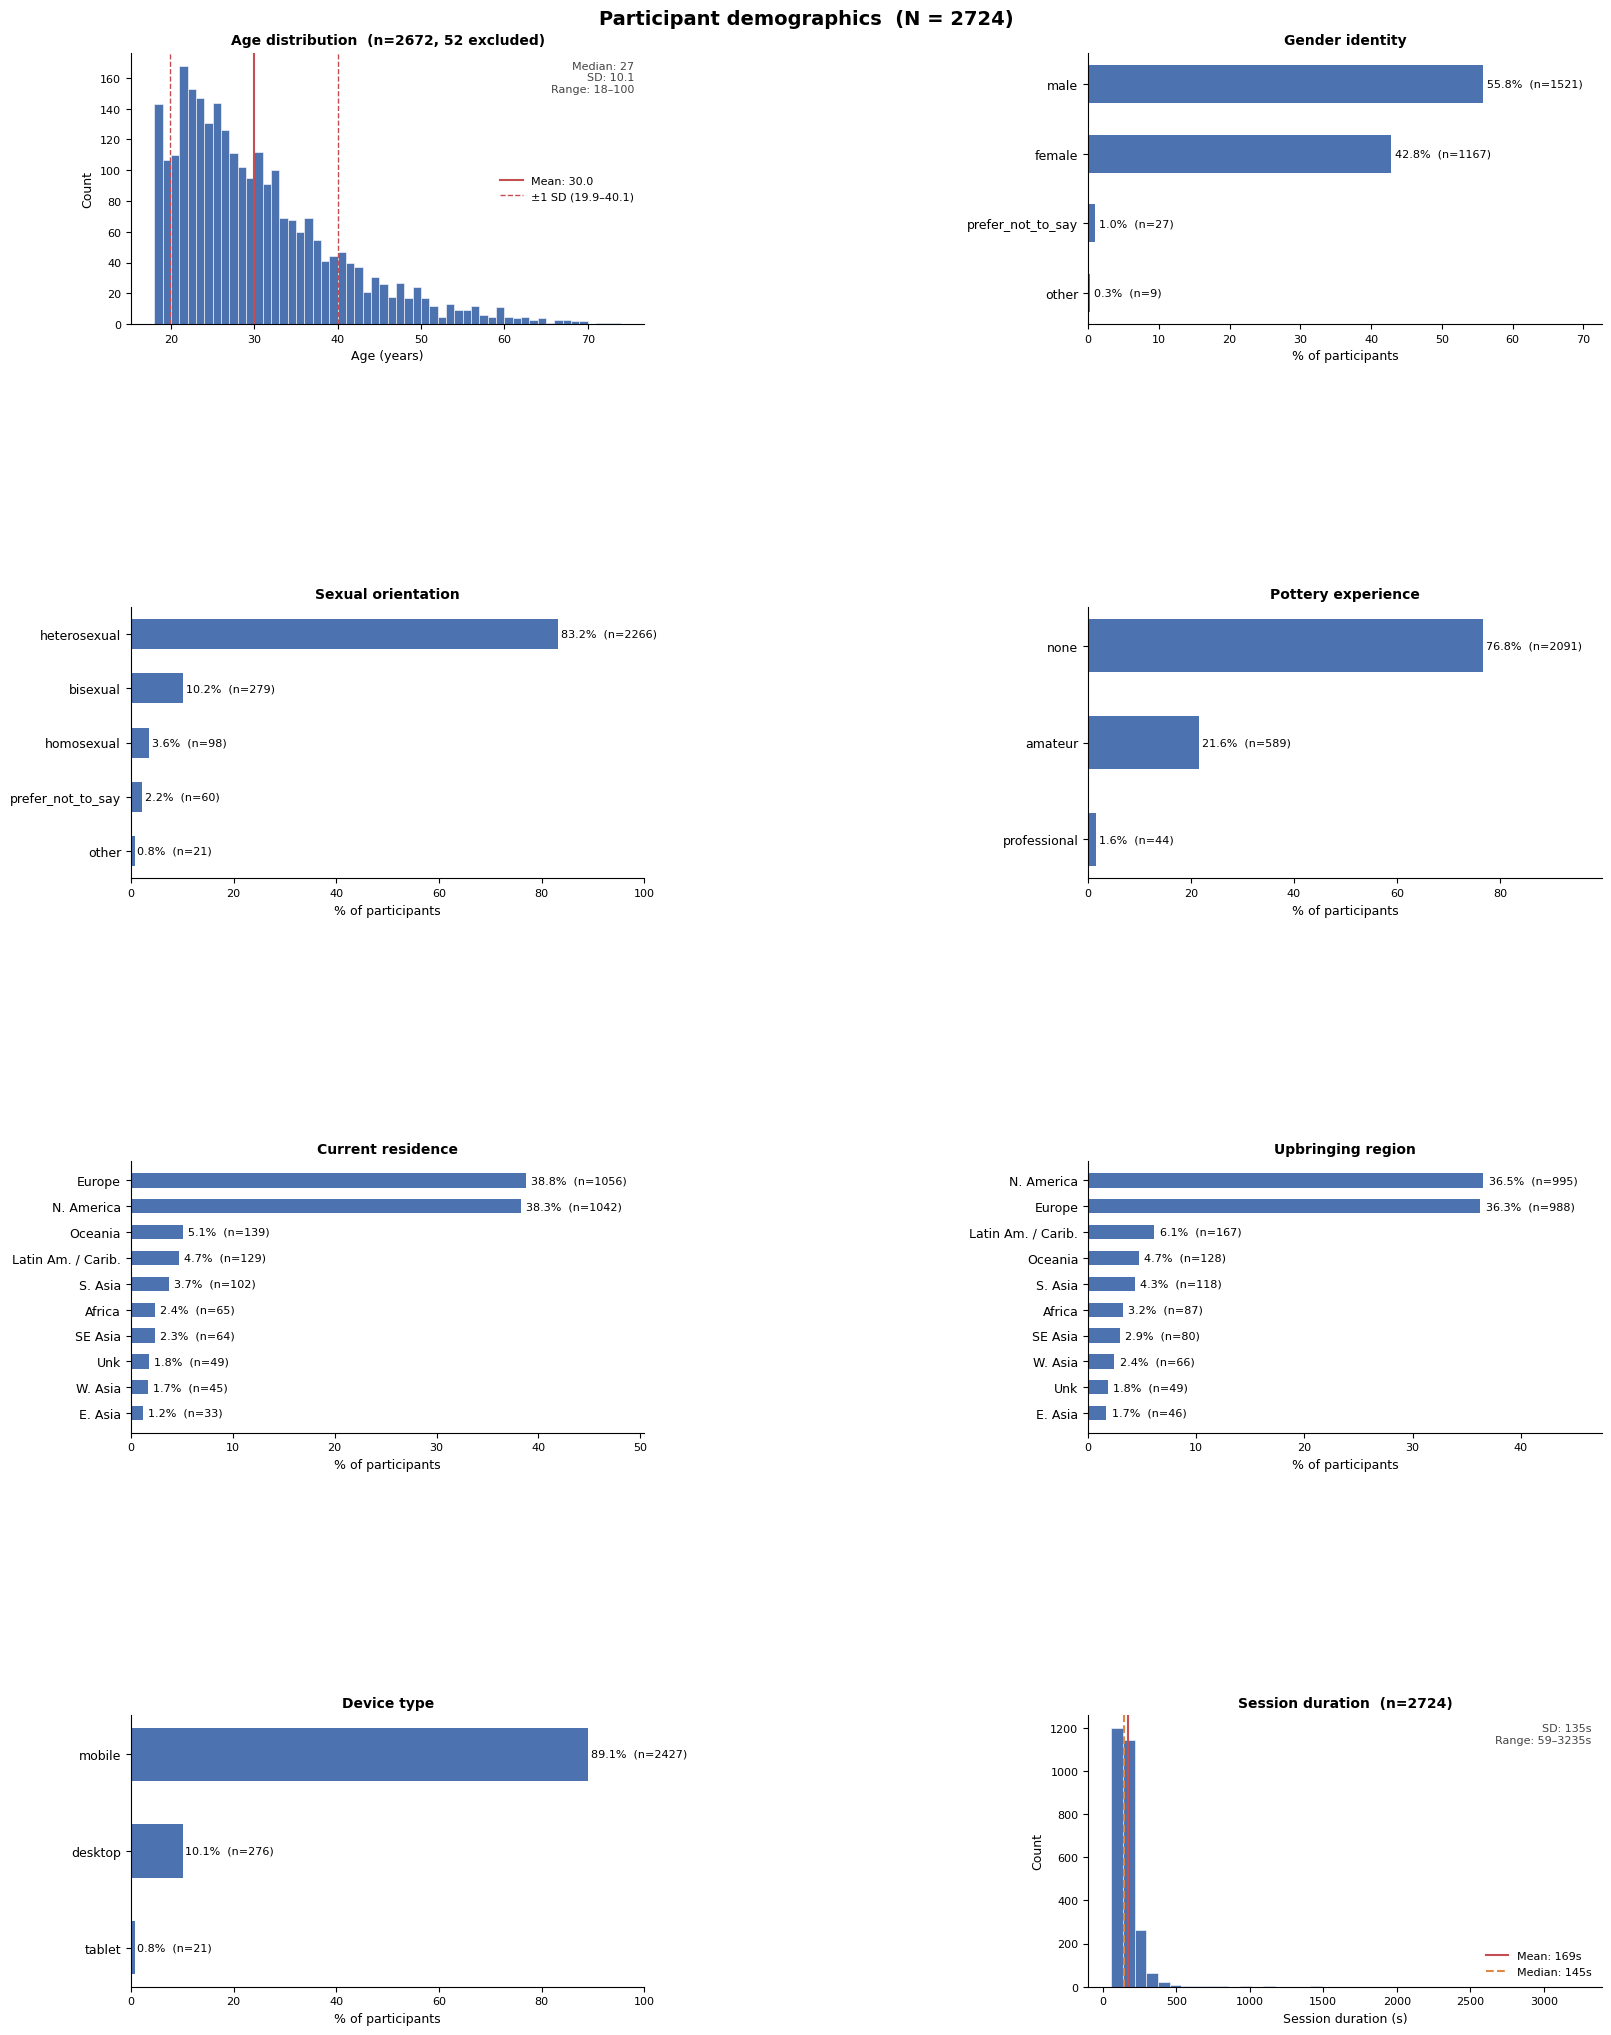


── Demographic Summary Table ─────────────────────────────────────────────────────────
  Age
                                                               n      %
Age                                                                    
mean 30.0  SD 10.1  median 27  range 18–100  (52 excluded)  2672  100.0

  Gender
                      n     %
Gender                       
male               1521  55.8
female             1167  42.8
prefer_not_to_say    27   1.0
other                 9   0.3

  Sexual orientation
                       n     %
Sexual orientation            
heterosexual        2266  83.2
bisexual             279  10.2
homosexual            98   3.6
prefer_not_to_say     60   2.2
other                 21   0.8

  Pottery experience
                       n     %
Pottery experience            
none                2091  76.8
amateur              589  21.6
professional          44   1.6

  Residence region
                       n     %
Residence region              
Eu

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path("processed")

# ── Friendly labels ───────────────────────────────────────────────────────────
REGION_LABELS = {
    "Eu": "Europe", "NAm": "N. America", "Oc": "Oceania",
    "SAs": "S. Asia", "Af": "Africa", "LAmC": "Latin Am. / Carib.",
    "WAs": "W. Asia", "SEAs": "SE Asia", "EAs": "E. Asia", "other": "Other",
}
POTTERY_ORDER = ["none", "amateur", "professional"]
ORIENT_ORDER  = ["heterosexual", "bisexual", "homosexual", "prefer_not_to_say", "other"]
GENDER_ORDER  = ["male", "female", "non_binary", "prefer_not_to_say", "other"]

BAR_COLOR = "#4C72B0"

# ── Load ──────────────────────────────────────────────────────────────────────
meta_path = OUTPUT_DIR / "metadata.parquet"
assert meta_path.exists(), "Run the pipeline first to generate metadata.parquet"
meta = pd.read_parquet(meta_path)
N = len(meta)

fc_path = OUTPUT_DIR / "final_choice.parquet"
assert fc_path.exists(), "Run the pipeline first to generate final_choice.parquet"
fc = pd.read_parquet(fc_path)

# ── Shared helpers ────────────────────────────────────────────────────────────
def _ordered_counts(series, order=None):
    vc = series.value_counts()
    if order:
        vc = vc.reindex([o for o in order if o in vc.index]).dropna()
    return vc

def _hbar(ax, series, title, order=None, label_map=None):
    vc = _ordered_counts(series, order)
    labels = [label_map.get(k, k) if label_map else k for k in vc.index]
    pcts   = vc.values / N * 100
    ax.barh(labels[::-1], pcts[::-1], color=BAR_COLOR, height=0.55)
    ax.set_xlabel("% of participants", fontsize=9)
    ax.set_xlim(0, min(max(pcts) * 1.3, 100))
    for i, (p, n) in enumerate(zip(pcts[::-1], vc.values[::-1])):
        ax.text(p + 0.5, i, f"{p:.1f}%  (n={n})", va="center", fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 20), constrained_layout=True)
fig.suptitle(f"Participant demographics  (N = {N})", fontsize=14, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_age      = fig.add_subplot(gs[0, 0])
ax_gender   = fig.add_subplot(gs[0, 1])
ax_orient   = fig.add_subplot(gs[1, 0])
ax_pot      = fig.add_subplot(gs[1, 1])
ax_res      = fig.add_subplot(gs[2, 0])
ax_upbr     = fig.add_subplot(gs[2, 1])
ax_device   = fig.add_subplot(gs[3, 0])
ax_duration = fig.add_subplot(gs[3, 1])

# Age histogram — exclude opt-out sentinel (1000) and any implausible value
age_s      = meta["age_years"].dropna()
n_excluded = (age_s > 120).sum()
age_s      = age_s[age_s <= 120]
age_mean   = age_s.mean()
age_sd     = age_s.std()
age_median = age_s.median()
age_min    = int(age_s.min())
age_max    = int(age_s.max())

ax_age.hist(age_s, bins=range(18, 75), color=BAR_COLOR, edgecolor="white", linewidth=0.4)
ax_age.axvline(age_mean,          color="#C44E52", linestyle="-",  linewidth=1.5, label=f"Mean: {age_mean:.1f}")
ax_age.axvline(age_mean - age_sd, color="#C44E52", linestyle="--", linewidth=1.0, label=f"±1 SD ({age_mean - age_sd:.1f}–{age_mean + age_sd:.1f})")
ax_age.axvline(age_mean + age_sd, color="#C44E52", linestyle="--", linewidth=1.0)
ax_age.set_xlabel("Age (years)", fontsize=9)
ax_age.set_ylabel("Count", fontsize=9)
title_note = f"  (n={len(age_s)}" + (f", {n_excluded} excluded)" if n_excluded else ")")
ax_age.set_title("Age distribution" + title_note, fontsize=10, fontweight="bold", pad=6)
ax_age.spines[["top", "right"]].set_visible(False)
ax_age.tick_params(labelsize=8)
ax_age.legend(fontsize=8, frameon=False)
ax_age.text(0.98, 0.97,
            f"Median: {age_median:.0f}\nSD: {age_sd:.1f}\nRange: {age_min}–{age_max}",
            transform=ax_age.transAxes, fontsize=8, va="top", ha="right", color="#444444")

# Horizontal bar charts
_hbar(ax_gender, meta["gender_identity"],               "Gender identity",    order=GENDER_ORDER)
_hbar(ax_orient, meta["sexual_orientation"],            "Sexual orientation", order=ORIENT_ORDER)
_hbar(ax_pot,    meta["pottery_experience_level"],      "Pottery experience", order=POTTERY_ORDER)
_hbar(ax_res,    meta["current_residence_region_code"], "Current residence",  label_map=REGION_LABELS)
_hbar(ax_upbr,   meta["upbringing_region_code"],        "Upbringing region",  label_map=REGION_LABELS)

# Device type bar chart (from metadata)
_hbar(ax_device, meta["device_type"], "Device type")

# Session duration histogram (from final_choice)
dur = fc["session_duration_s"].dropna()
dur_mean   = dur.mean()
dur_median = dur.median()
dur_sd     = dur.std()
ax_duration.hist(dur, bins=40, color=BAR_COLOR, edgecolor="white", linewidth=0.4)
ax_duration.axvline(dur_mean,   color="#C44E52", linestyle="-",  linewidth=1.5, label=f"Mean: {dur_mean:.0f}s")
ax_duration.axvline(dur_median, color="#DD8844", linestyle="--", linewidth=1.5, label=f"Median: {dur_median:.0f}s")
ax_duration.set_xlabel("Session duration (s)", fontsize=9)
ax_duration.set_ylabel("Count", fontsize=9)
ax_duration.set_title(f"Session duration  (n={len(dur)})", fontsize=10, fontweight="bold", pad=6)
ax_duration.spines[["top", "right"]].set_visible(False)
ax_duration.tick_params(labelsize=8)
ax_duration.legend(fontsize=8, frameon=False)
ax_duration.text(0.98, 0.97,
                 f"SD: {dur_sd:.0f}s\nRange: {dur.min():.0f}–{dur.max():.0f}s",
                 transform=ax_duration.transAxes, fontsize=8, va="top", ha="right", color="#444444")

plt.savefig(OUTPUT_DIR / "demographics.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
def _summary_table(series, label, order=None, label_map=None):
    vc = _ordered_counts(series, order)
    df = pd.DataFrame({"n": vc, "%": (vc / N * 100).round(1)})
    if label_map:
        df.index = [label_map.get(i, i) for i in df.index]
    df.index.name = label
    return df

age_row = pd.DataFrame({"n": [int(age_s.count())], "%": [100.0]}, index=pd.Index(
    [f"mean {age_mean:.1f}  SD {age_sd:.1f}  median {age_median:.0f}  range {age_min}–{age_max}"
     + (f"  ({n_excluded} excluded)" if n_excluded else "")],
    name="Age"))

tables = {
    "Age":                age_row,
    "Gender":             _summary_table(meta["gender_identity"],               "Gender",             GENDER_ORDER),
    "Sexual orientation": _summary_table(meta["sexual_orientation"],            "Sexual orientation", ORIENT_ORDER),
    "Pottery experience": _summary_table(meta["pottery_experience_level"],      "Pottery experience", POTTERY_ORDER),
    "Residence region":   _summary_table(meta["current_residence_region_code"], "Residence region",   label_map=REGION_LABELS),
    "Upbringing region":  _summary_table(meta["upbringing_region_code"],        "Upbringing region",  label_map=REGION_LABELS),
    "Device type":        _summary_table(meta["device_type"],                   "Device type"),
}
print("\n── Demographic Summary Table ─────────────────────────────────────────────────────────")
for title, tbl in tables.items():
    print(f"  {title}")
    print(tbl.to_string())
    print()